# L1.1 — Loss Functions

Hands-on notebook for the lesson [`1-1-loss-function.mdx`](../../llm-quest-theory/level-1/1-1-loss-function.mdx).

> **Learning objectives**
> - Feel the behavior of MSE vs MAE on clean and outlier-contaminated data.
> - Implement Binary Cross-Entropy and understand its "infinite-penalty-when-confidently-wrong" shape.
> - Visualize the MSE loss surface for a 2-parameter model and locate its minimum.
> - Get a preview of categorical cross-entropy — the loss every LLM trains on.

## Connection to the theory
This notebook covers **§1–§4** of the source `.mdx`. Loss functions answer the question "how wrong is the model?" — without them we have no target to minimize.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. MSE and MAE on a clean dataset

$$\mathrm{MSE}=\frac{1}{N}\sum_i(\hat y_i - y_i)^2,\qquad \mathrm{MAE}=\frac{1}{N}\sum_i|\hat y_i - y_i|$$

In [2]:
def mse(y, y_hat):
    return float(np.mean((y_hat - y) ** 2))

def mae(y, y_hat):
    return float(np.mean(np.abs(y_hat - y)))

# Clean toy data: y = 2x + 1 + small noise
N = 30
x = np.linspace(0, 4, N)
y = 2 * x + 1 + np.random.normal(0, 0.4, size=N)

# Try a constant prediction and a decent linear fit
print("constant y_hat = 5:")
print(f"  MSE = {mse(y, np.full_like(y, 5.0)):.3f}")
print(f"  MAE = {mae(y, np.full_like(y, 5.0)):.3f}")

print("linear y_hat = 2x + 1:")
print(f"  MSE = {mse(y, 2*x + 1):.3f}")
print(f"  MAE = {mae(y, 2*x + 1):.3f}")

constant y_hat = 5:
  MSE = 5.251
  MAE = 1.995
linear y_hat = 2x + 1:
  MSE = 0.131
  MAE = 0.292


## 2. Inject an outlier and compare
A single far-off point can drag the MSE-optimal line away from the clean trend. MAE is more stubborn.

In [3]:
# Add one outlier
x_out = np.append(x, 4.0)
y_out = np.append(y, 30.0)

# Fit by brute-force grid search for MSE and MAE
aa = np.linspace(0, 10, 400)
bb = np.linspace(-5, 15, 400)
AA, BB = np.meshgrid(aa, bb)
preds = AA[..., None] * x_out + BB[..., None]
loss_mse = ((preds - y_out) ** 2).mean(axis=-1)
loss_mae = np.abs(preds - y_out).mean(axis=-1)

i_mse = np.unravel_index(np.argmin(loss_mse), loss_mse.shape)
i_mae = np.unravel_index(np.argmin(loss_mae), loss_mae.shape)
a_mse, b_mse = AA[i_mse], BB[i_mse]
a_mae, b_mae = AA[i_mae], BB[i_mae]

print(f"MSE-optimal: a={a_mse:.2f}, b={b_mse:.2f}")
print(f"MAE-optimal: a={a_mae:.2f}, b={b_mae:.2f}")
print("Ground-truth (clean):  a=2.00, b=1.00")

MSE-optimal: a=2.78, b=0.01
MAE-optimal: a=1.95, b=0.96
Ground-truth (clean):  a=2.00, b=1.00


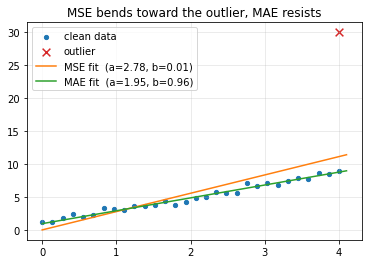

In [4]:
fig, ax = plt.subplots()
ax.scatter(x, y, label="clean data", color="tab:blue", s=18)
ax.scatter([x_out[-1]], [y_out[-1]], label="outlier", color="tab:red", s=60, marker="x")
xs = np.linspace(0, 4.1, 50)
ax.plot(xs, a_mse * xs + b_mse, color="tab:orange", label=f"MSE fit  (a={a_mse:.2f}, b={b_mse:.2f})")
ax.plot(xs, a_mae * xs + b_mae, color="tab:green",  label=f"MAE fit  (a={a_mae:.2f}, b={b_mae:.2f})")
ax.grid(alpha=0.3); ax.legend(); ax.set_title("MSE bends toward the outlier, MAE resists")
plt.show()

## 3. Binary Cross-Entropy (BCE)

$$L = -\frac{1}{N}\sum_i\Big[y_i\log\hat y_i + (1-y_i)\log(1-\hat y_i)\Big]$$

The loss is *infinite* when the model is confident and wrong. Let's see it with two data points: one with true label 1, one with true label 0.

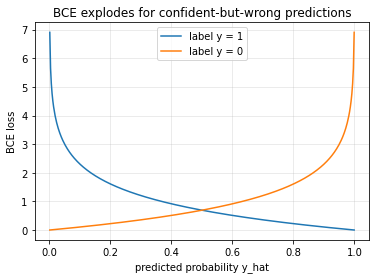

In [5]:
def bce(y, y_hat, eps=1e-12):
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

p = np.linspace(0.001, 0.999, 400)

fig, ax = plt.subplots()
ax.plot(p, [bce(np.array([1.0]), np.array([pi])) for pi in p], label="label y = 1")
ax.plot(p, [bce(np.array([0.0]), np.array([pi])) for pi in p], label="label y = 0")
ax.set_xlabel("predicted probability y_hat"); ax.set_ylabel("BCE loss")
ax.set_title("BCE explodes for confident-but-wrong predictions")
ax.grid(alpha=0.3); ax.legend(); plt.show()

Observation: the curve for `y = 1` is near zero when `y_hat -> 1` and skyrockets as `y_hat -> 0`. BCE gives the model a huge incentive not to be arrogant and wrong.

## 4. Why not use MSE for classification?
MSE is much flatter where it matters — the gradient vanishes, so training stalls. Compare the two losses on the same point with label `y = 1`.

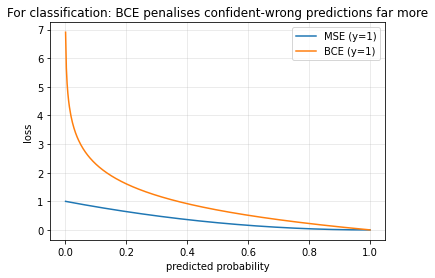

In [6]:
# For a single label y=1:
#   MSE(y_hat) = (1 - y_hat)^2
#   BCE(y_hat) = -log(y_hat)
fig, ax = plt.subplots()
ax.plot(p, (1 - p) ** 2, label="MSE (y=1)")
ax.plot(p, -np.log(p),    label="BCE (y=1)")
ax.set_xlabel("predicted probability"); ax.set_ylabel("loss")
ax.set_title("For classification: BCE penalises confident-wrong predictions far more")
ax.grid(alpha=0.3); ax.legend(); plt.show()

## 5. MSE loss surface for a 2-parameter model
Back to regression. Plot `MSE(a, b)` for the clean data — this is the landscape that gradient descent will walk across in the next lesson.

Minimum found on the grid: a = 1.87, b = 1.21


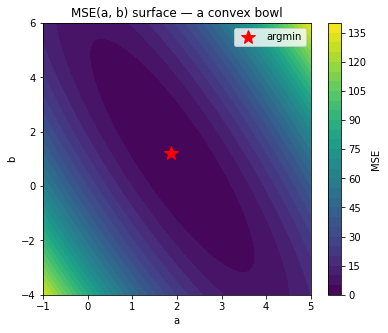

In [7]:
aa = np.linspace(-1, 5, 120)
bb = np.linspace(-4, 6, 120)
AA, BB = np.meshgrid(aa, bb)
preds = AA[..., None] * x + BB[..., None]
loss_surface = ((preds - y) ** 2).mean(axis=-1)

i = np.unravel_index(np.argmin(loss_surface), loss_surface.shape)
print(f"Minimum found on the grid: a = {AA[i]:.2f}, b = {BB[i]:.2f}")

fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contourf(AA, BB, loss_surface, levels=30, cmap="viridis")
ax.plot(AA[i], BB[i], "r*", markersize=14, label="argmin")
ax.set_xlabel("a"); ax.set_ylabel("b"); ax.set_title("MSE(a, b) surface — a convex bowl")
plt.colorbar(cs, ax=ax, label="MSE"); ax.legend(); plt.show()

## 6. Categorical Cross-Entropy — the LLM loss
An LLM predicts a distribution over the vocabulary at every token position. The ground-truth token `y` is one-hot, and the loss is `-log p_y`, i.e. the negative log-probability the model assigned to the true token.

In [8]:
def softmax(z):
    z = z - z.max()                    # numerical stability
    e = np.exp(z)
    return e / e.sum()

def cross_entropy(logits, y_true_idx):
    probs = softmax(logits)
    return float(-np.log(probs[y_true_idx] + 1e-12))

# Toy vocabulary of 4 tokens: ["cat", "dog", "fish", "bird"]
vocab = ["cat", "dog", "fish", "bird"]
logits_good = np.array([3.0, 0.5, 0.2, -1.0])   # model very sure it's "cat"
logits_bad  = np.array([-1.0, 0.2, 0.5, 3.0])   # model thinks "bird"
y_true = 0  # "cat"

for name, logits in [("good", logits_good), ("bad", logits_bad)]:
    p = softmax(logits)
    print(f"{name} prediction: probs={np.round(p, 3)}  loss={cross_entropy(logits, y_true):.3f}")

good prediction: probs=[0.861 0.071 0.052 0.016]  loss=0.149
bad prediction: probs=[0.016 0.052 0.071 0.861]  loss=4.149


## 7. Quick checks

In [9]:
assert mse(np.array([1.0, 2.0]), np.array([1.0, 2.0])) == 0.0
assert mae(np.array([0.0]),      np.array([3.0])) == 3.0
assert np.isclose(softmax(np.array([0.0, 0.0, 0.0])).sum(), 1.0)
# BCE: predicting 0.5 for every label is ln(2) regardless of the true label
assert abs(bce(np.array([1.0]), np.array([0.5])) - np.log(2)) < 1e-6
print("OK — loss toolbox looks consistent.")

OK — loss toolbox looks consistent.


## Reflection questions

1. Why does MAE produce a non-smooth loss landscape at the minimum while MSE is smooth everywhere?
2. In section 3, we added `eps` inside the log. What happens numerically if we remove it and the model ever outputs exactly 0 or 1?
3. A training loss of 0 is usually a warning sign — of what? (Hint: see L2-3 preview.)
4. For a token prediction task with a 50 000-word vocabulary, what does a cross-entropy of `log(50000)` mean intuitively?

## References
- Source theory: [`1-1-loss-function.mdx`](../../llm-quest-theory/level-1/1-1-loss-function.mdx)
- Next: [`1-2-gradient-descent`](1-2-gradient-descent.ipynb)